# Link prediction: feature engineering and prediction

Second notebook of the pipeline (after the exploration in `mimo1.ipynb`). It builds a **leakage-free training set** and a **well-motivated feature space** for predicting the missing links, then selects and validates a model, predicts the 1416 test pairs, and looks at how errors are distributed across groups (input for the ethics essay).

**Outputs** (`../output/features/`):
- `train_features.csv`: labelled node pairs (positives = held-out edges, negatives = random non-edges). Every pair's features are computed on a graph from which its fold of edges was removed. The `fold` column is meant for grouped cross-validation.
- `test_features.csv`: the 1416 pairs of `solutionInput.csv` with the same features, computed on the full visible graph.
- `feature_groups.json`: feature names by group (including the sensitive-attribute group, for ablations in the ethics part) and a recommended subset.
- `../output/submission.csv`: the final predictions (`ID`, `prediction`).

**Outline**
1. Data
2. What structure can we exploit? (degree, homophily, communities)
3. Building training pairs that look like the test pairs (and avoiding leakage)
4. Feature definitions
5. Computing the features
6. Feature analysis: signal, redundancy, train/test shift, group ablation
7. Selection and export
8. Validation design
9. Model selection with grouped cross-validation
10. Shift-aware validation on a pseudo-test
11. Final model and submission
12. Who gets the errors? (fairness analysis)
13. Error rates per attribute value (input for the ethics essay)

Summary

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from joblib import Parallel, delayed
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, normalized_mutual_info_score
from sklearn.model_selection import GridSearchCV, GroupKFold, cross_val_predict, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.tree import DecisionTreeClassifier

SEED = 42
N_FOLDS = 20     # each fold holds out 1/N_FOLDS of the visible edges as positives (section 3)
NEG_RATIO = 1    # negatives per positive; the test set is balanced (708 / 708)
INPUT = Path('../input')
OUTPUT = Path('../output/features')

In [2]:
# Plot style. Categorical colours come from a colour-blind-validated palette, used in fixed order.
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']   # blue, orange, aqua, yellow, magenta
POS, NEG = C[0], C[1]                                         # link / no link
INK, INK2, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
SEQ = mpl.colors.LinearSegmentedColormap.from_list('seq', ['#f0efec', '#86b6ef', '#2a78d6', '#0d366b'])
DIV = mpl.colors.LinearSegmentedColormap.from_list('div', ['#184f95', '#86b6ef', '#f0efec', '#ec9090', '#b83232'])
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'savefig.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'font.size': 9, 'lines.linewidth': 2, 'legend.frameon': False, 'figure.dpi': 110,
})

## 1. Data

All 1800 nodes are added explicitly, so a node that loses all its edges in a training fold still exists in that fold's graph.

In [3]:
nodes = pd.read_csv(INPUT / 'attributes.csv')
edges = pd.read_csv(INPUT / 'edges_train.edgelist', header=None, names=['u', 'v'])
test_pairs = pd.read_csv(INPUT / 'solutionInput.csv')

N = len(nodes)
attr = nodes.set_index('ID')['attribute'].reindex(range(N)).to_numpy()
attr_codes = pd.Categorical(attr).codes          # 'a'..'f' -> 0..5

G = nx.Graph()
G.add_nodes_from(range(N))
G.add_edges_from(edges.itertuples(index=False))
nx.set_node_attributes(G, dict(enumerate(attr)), 'attribute')

E = np.sort(np.array(G.edges()), axis=1)          # visible edges as (u, v) with u < v
degree = np.array([d for _, d in G.degree()])
test_arr = test_pairs[['int1', 'int2']].to_numpy()

In [4]:
k = degree
vc = pd.Series(attr).value_counts().sort_index()
pd.Series({
    'nodes': N,
    'visible edges': G.number_of_edges(),
    'density': round(nx.density(G), 5),
    'mean degree': round(k.mean(), 2),
    'median / max degree': f'{np.median(k):.0f} / {k.max()}',
    'connected components': nx.number_connected_components(G),
    'average clustering': round(nx.average_clustering(G), 3),
    'attribute assortativity': round(nx.attribute_assortativity_coefficient(G, 'attribute'), 3),
    'degree assortativity': round(nx.degree_assortativity_coefficient(G), 3),
    'nodes per attribute value (a-f)': ' / '.join(map(str, vc)),
    'test pairs': len(test_pairs),
    'test pairs that are edges of the visible graph': sum(G.has_edge(a, b) for a, b in test_arr),
}, dtype=object).to_frame('value')

,value
nodes,1800
visible edges,6377
density,0.00394
mean degree,7.09
median / max degree,5 / 62
connected components,1
average clustering,0.109
attribute assortativity,0.446
degree assortativity,-0.122
nodes per attribute value (a-f),300 / 300 / 300 / 300 / 300 / 300


## 2. What structure can we exploit?

The assignment points to three regularities of social networks: **high clustering** (triadic closure), **homophily** and **communities**. Each one motivates a feature group in section 4. Here we check homophily and communities, together with degree heterogeneity; triadic closure is covered by the classic neighbourhood features.

### 2.1 Degree heterogeneity

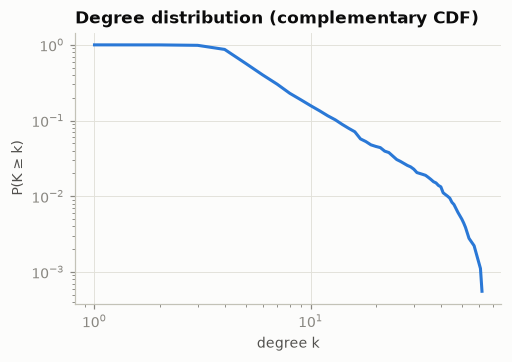

mean degree of a random node:    7.1
mean degree of an edge endpoint: 13.7


In [5]:
vals, counts = np.unique(degree, return_counts=True)
ccdf = 1 - np.r_[0, np.cumsum(counts)[:-1]] / N            # P(K >= k)

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.loglog(vals, ccdf, color=C[0])
ax.set(xlabel='degree k', ylabel='P(K ≥ k)', title='Degree distribution (complementary CDF)')
plt.show()

print(f'mean degree of a random node:    {degree.mean():.1f}')
print(f'mean degree of an edge endpoint: {(degree**2).mean() / degree.mean():.1f}')

The degree distribution is heavy-tailed (median 5, maximum 62). An edge endpoint has on average about twice the degree of a random node, so **hubs take part in a disproportionate share of links**. This motivates the degree and centrality features (`deg_*`, `pagerank_*`, `pref_attach`, ...).

### 2.2 Homophily

Observed edges between attribute groups divided by the number expected if edges ignored the attribute, given each group's total degree. A value of 1 means no preference.

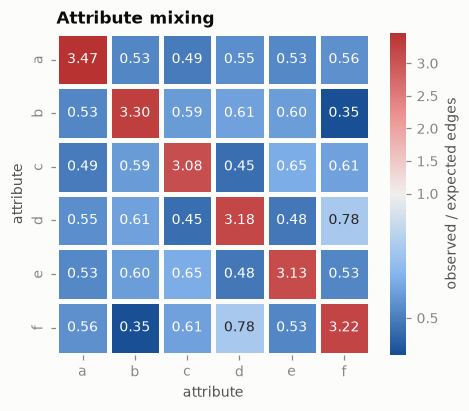

share of edges between same-attribute nodes: 0.54 (random mixing would give 0.17)


In [6]:
A_full = nx.to_numpy_array(G, nodelist=range(N))
Z = np.eye(attr_codes.max() + 1)[attr_codes]                 # one-hot attribute membership
observed = Z.T @ A_full @ Z                                  # edge endpoints between groups (diagonal counted twice)
group_degree = Z.T @ degree
expected = np.outer(group_degree, group_degree) / degree.sum()
labels = sorted(set(attr))
mixing = pd.DataFrame(observed / expected, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(4.6, 3.8))
norm = mpl.colors.TwoSlopeNorm(vmin=mixing.values.min(), vcenter=1, vmax=mixing.values.max())
sns.heatmap(mixing, annot=True, fmt='.2f', cmap=DIV, norm=norm, linewidths=2, linecolor='#fcfcfb',
            cbar_kws={'label': 'observed / expected edges'}, ax=ax)
ax.set(xlabel='attribute', ylabel='attribute', title='Attribute mixing')
plt.show()
print(f'share of edges between same-attribute nodes: {(attr[E[:, 0]] == attr[E[:, 1]]).mean():.2f} '
      f'(random mixing would give {(group_degree**2).sum() / degree.sum()**2:.2f})')

Strong homophily: same-attribute pairs are linked about 3× more often than random mixing predicts. Off the diagonal every pair is below 1, but not uniformly: d–f (0.78) is only mildly avoided, while b–f (0.35) is strongly avoided. `same_attr` alone misses this pattern; `attr_mixing_ratio` and `dcsbm_attr` capture the full 6×6 matrix. This motivates the attribute features. **The attribute may be sensitive** (political affiliation, demographics, ...), so these features are kept in a separate group. That lets us measure later what using it actually buys in accuracy.

### 2.3 Communities

communities: 6, sizes: [306, 302, 300, 300, 300, 292]
modularity: Louvain 0.74 vs attribute partition 0.37
share of edges inside a community: 0.91, inside an attribute group: 0.54
NMI(community, attribute): 0.47


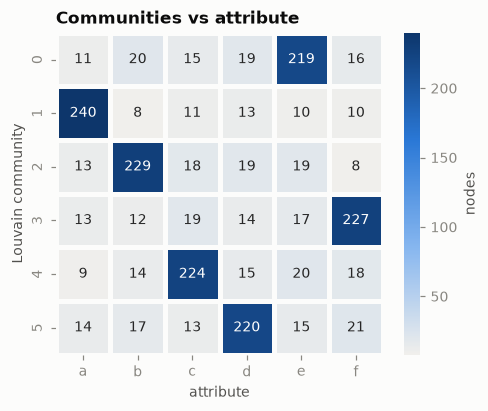

In [7]:
def louvain_labels(H, seed):
    """Louvain community label of every node (array indexed by node id)."""
    labels = np.empty(N, dtype=int)
    for c, members in enumerate(nx.community.louvain_communities(H, seed=seed)):
        labels[list(members)] = c
    return labels

comm = louvain_labels(G, SEED)
partition = [set(np.flatnonzero(comm == c)) for c in range(comm.max() + 1)]
print(f'communities: {len(partition)}, sizes: {sorted(map(len, partition), reverse=True)}')
print(f'modularity: Louvain {nx.community.modularity(G, partition):.2f} vs attribute partition '
      f'{nx.community.modularity(G, [set(np.flatnonzero(attr_codes == a)) for a in range(6)]):.2f}')
print(f'share of edges inside a community: {(comm[E[:, 0]] == comm[E[:, 1]]).mean():.2f}, '
      f'inside an attribute group: {(attr_codes[E[:, 0]] == attr_codes[E[:, 1]]).mean():.2f}')
print(f'NMI(community, attribute): {normalized_mutual_info_score(attr_codes, comm):.2f}')

ct = pd.crosstab(pd.Series(comm, name='Louvain community'), pd.Series(attr, name='attribute'))
fig, ax = plt.subplots(figsize=(4.8, 3.8))
sns.heatmap(ct, annot=True, fmt='d', cmap=SEQ, linewidths=2, linecolor='#fcfcfb', cbar_kws={'label': 'nodes'}, ax=ax)
ax.set_title('Communities vs attribute')
plt.show()

This is the most important structural finding:
- Louvain finds **6 communities of about 300 nodes** with very high modularity, and about **90% of all edges fall inside a community**, against about 54% inside an attribute group.
- Each community is dominated (about 75%) by one attribute value. The rest of its members are spread evenly over the other values. **The attribute behaves like a noisy label of a hidden community.**

Two consequences:
1. Community features should be the strongest predictors, stronger than the attribute itself.
2. *(Ethics)* Even if we drop the sensitive attribute, community features act as a **proxy** for it. This is a classic "fairness through unawareness fails" case, and the ablation in section 6.5 quantifies it.

## 3. Building training pairs that look like the test pairs

The test set consists of 708 edges removed from the original network and 708 non-edges. Two things follow.

**(i) Positives must not be in the graph the features are computed on.** None of the 1416 test pairs is an edge of the visible graph (table in section 1). If training positives were edges of the graph used for features, every feature touching the pair would "see" the edge: distance would be 1, degrees would be inflated by 1, clustering would be inflated, and so on. The model would learn from information that never exists at test time, and validation accuracy would be optimistic. That was the issue in `mimo1.ipynb`. So for training we **hold edges out**, compute features on the remaining graph, and use the held-out edges as positives.

**(ii) The training pairs should be sampled like the test pairs.** We assume the organisers removed edges uniformly at random (about 10%) and sampled the negatives uniformly among non-edges. The training pairs are built the same way:
- **Positives:** uniformly random held-out edges.
- **Negatives:** uniformly random non-edges.
- **Ratio 1:1**, like the test set.

### Construction: K-fold edge hold-out

1. Split the 6377 visible edges into `N_FOLDS` disjoint folds.
2. For fold *k*: the graph is $G_k = G \setminus \text{fold}_k$, the positives are the fold-*k* edges, and the negatives are uniformly random non-edges of $G$. **All features of fold-*k* pairs are computed on $G_k$ only.**
3. Every visible edge is a positive exactly once, which gives 6377 positives and 6377 negatives.
4. Negatives also exclude the 1416 test pairs. No hidden link can end up labelled 0, and training and test pairs never overlap. This uses only the pair list, never test labels.

**Why 20 folds (5% per fold) instead of 10%?** Test features are computed on $G$ with all 6377 visible edges, while $G_k$ keeps only $(1 - 1/K)$ of them. Count-based features (degrees, common neighbours, paths) are therefore systematically smaller in training than in test. A smaller hold-out keeps $G_k$ closer to $G$. In a trial run (not shown), going from 10 to 20 folds lowered the mean per-feature shift AUC (section 6.4) from 0.546 to 0.527, about 40% closer to 0.5 (no shift). The `fold` column is also the natural group for cross-validation later, since pairs in the same fold share a graph.

In [8]:
def sample_non_edges(n_pairs, forbidden, rng):
    """Uniformly random node pairs (u < v) that are not in the set `forbidden`."""
    out = set()
    while len(out) < n_pairs:
        u, v = sorted(rng.choice(N, size=2, replace=False).tolist())
        if (u, v) not in forbidden:
            out.add((u, v))
    return np.array(sorted(out))


def make_training_pairs(G, n_folds, neg_ratio, exclude, seed):
    """Positives = visible edges split into folds; negatives = uniform non-edges assigned to folds."""
    rng = np.random.default_rng(seed)
    E = np.sort(np.array(G.edges()), axis=1)
    pos_fold = rng.permutation(np.arange(len(E)) % n_folds)
    neg = sample_non_edges(round(neg_ratio * len(E)), set(map(tuple, E)) | exclude, rng)
    neg_fold = rng.permutation(np.arange(len(neg)) % n_folds)
    pairs = pd.DataFrame(np.vstack([E, neg]), columns=['u', 'v'])
    pairs['label'] = np.r_[np.ones(len(E), dtype=int), np.zeros(len(neg), dtype=int)]
    pairs['fold'] = np.r_[pos_fold, neg_fold]
    return pairs.sort_values(['fold', 'label', 'u', 'v'], ascending=[True, False, True, True], ignore_index=True)


test_set = set(map(tuple, np.sort(test_arr, axis=1)))
train_pairs = make_training_pairs(G, N_FOLDS, NEG_RATIO, exclude=test_set, seed=SEED)
pd.crosstab(train_pairs.label, train_pairs.fold)

fold,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
label,,,,,,,,,,,,,,,,,,,,
0,319,319,319,319,319,319,319,319,319,319,319,319,319,319,319,319,319,318,318,318
1,319,319,319,319,319,319,319,319,319,319,319,319,319,319,319,319,319,318,318,318


## 4. Feature definitions

Every feature is **symmetric in (u, v)** because the graph is undirected, and it is computed **only from the graph the pair is scored on** ($G_k$ for training, $G$ for test). Notation: $\Gamma(u)$ is the neighbour set and $k_u$ the degree of $u$.

| Group | Features | Definition | Why |
|---|---|---|---|
| **Node** | `deg`, `clust`, `core`, `pagerank`, `betw`, `close`, `avg_nbr_deg`, each as `_min` / `_max` over the two endpoints | degree, clustering coefficient, k-core number, PageRank, betweenness, closeness, mean neighbour degree | popular nodes attract links (2.1); min/max keeps features symmetric |
| **Neighbourhood** | `common_neighbors`, `jaccard`, `adamic_adar`, `resource_alloc`, `pref_attach`, `salton`, `sorensen`, `hub_promoted`, `hub_depressed`, `lhn` | functions of $\Gamma(u)\cap\Gamma(v)$ and $k_u, k_v$, e.g. Adamic–Adar $\sum_{z\in\Gamma(u)\cap\Gamma(v)} 1/\log k_z$, preferential attachment $k_u k_v$. The first five are networkx's link-prediction functions (`nx.common_neighbors`, `nx.jaccard_coefficient`, ...); networkx has no function for the last five, which are ratios of the common-neighbour count and the degrees | triadic closure (friends of friends tend to become friends); the classic indices of Liben-Nowell & Kleinberg |
| **Path** | `shortest_path`, `paths_3`, `katz`, `rooted_pagerank` | hop distance (`nx.shortest_path_length`); number of paths u–w–x–v of length 3 (for every neighbour w of u, the common neighbours of w and v); Katz $\sum_\ell \beta^\ell (A^\ell)_{uv}$ with $\beta = 0.5/\lambda_{max}$; random walk with restart ($\alpha = 0.85$) from u ending at v, plus from v ending at u (`nx.pagerank` personalised on the start node) | most hidden edges have no common neighbour (6.2), so we need proximity beyond 2 hops |
| **Community** | `same_comm_frac`, `dcsbm_comm`, `nbr_comm_affinity`, `spectral_cos` | share of 10 Louvain runs (`nx.community.louvain_communities`) placing u and v together; degree-corrected SBM score (below) with Louvain blocks; share of u's neighbours in v's community (averaged both ways); cosine of the 6-dim spectral embedding | 90% of edges are inside communities (2.3) |
| **Attribute** *(sensitive)* | `same_attr`, `attr_mixing_ratio`, `nbr_attr_affinity`, `dcsbm_attr` | same value; edge density between the two attribute groups (from `nx.attribute_mixing_matrix`) ÷ overall density (`nx.density`); share of u's neighbours with v's attribute (both ways); DC-SBM score with attribute blocks | homophily (2.2) |

**DC-SBM score.** The expected number of edges between u and v under a degree-corrected stochastic block model fitted to the graph (Karrer & Newman, 2011): $\lambda_{uv} = k_u k_v \, m_{rs} / (\kappa_r \kappa_s)$. Here $r, s$ are the blocks of u and v, $m_{rs}$ is the number of edges between the blocks (counted twice for $r = s$; `nx.attribute_mixing_matrix`), and $\kappa_r$ is the total degree of block $r$. It combines "how popular are u and v" with "how strongly do their groups connect" in a single number. If the data were generated by such a model, this would be close to the ideal score.

**Robustness choices.** Louvain is randomised, so `same_comm_frac` averages 10 runs, and the block features use the run with the highest `nx.community.modularity`. The spectral embedding (leading eigenvectors of $D^{-1/2} A D^{-1/2}$, rows normalised, Ng–Jordan–Weiss) gives a soft community membership for nodes on community borders. `attr_mixing_ratio` is divided by the overall density so it does not shift with graph density.

**Implementation.** Everything is computed with networkx except Katz and the spectral embedding: networkx has no pairwise Katz index and no spectral embedding, so these two use the adjacency matrix. `nx.pagerank` runs with a tight tolerance (`tol=1e-15`) and starts the iteration at the restart node. In a check (not shown) it matched the exact matrix solution to within 2e-10 relative, with the same ranking of pairs.

In [9]:
KATZ_DAMPING = 0.5   # Katz beta as a fraction of 1 / lambda_max (must be < 1)
RPR_ALPHA = 0.85     # rooted PageRank: probability of continuing the walk (restart prob. 0.15)
SPECTRAL_DIM = 6     # one eigenvector per expected community
N_LOUVAIN = 10       # Louvain runs per graph
UNREACHABLE = 10     # distance used for disconnected pairs (the diameter is 7)

NODE_METRICS = ['deg', 'clust', 'core', 'pagerank', 'betw', 'close', 'avg_nbr_deg']
FEATURE_GROUPS = {
    'node': [f'{m}_{agg}' for m in NODE_METRICS for agg in ('min', 'max')],
    'neighbourhood': ['common_neighbors', 'jaccard', 'adamic_adar', 'resource_alloc', 'pref_attach',
                      'salton', 'sorensen', 'hub_promoted', 'hub_depressed', 'lhn'],
    'path': ['shortest_path', 'paths_3', 'katz', 'rooted_pagerank'],
    'community': ['same_comm_frac', 'dcsbm_comm', 'nbr_comm_affinity', 'spectral_cos'],
    'attribute': ['same_attr', 'attr_mixing_ratio', 'nbr_attr_affinity', 'dcsbm_attr'],
}
FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]
GROUP_OF = {f: g for g, fs in FEATURE_GROUPS.items() for f in fs}

In [10]:
def safe_div(a, b):
    """Element-wise a / b with 0 where b == 0."""
    a, b = np.broadcast_arrays(np.asarray(a, dtype=float), np.asarray(b, dtype=float))
    return np.divide(a, b, out=np.zeros_like(a), where=b > 0)


def node_metrics(H):
    """Per-node metrics of graph H, as arrays indexed by node id."""
    to_array = lambda d: np.array([d[i] for i in range(N)], dtype=float)
    return {
        'deg': to_array(dict(H.degree())),
        'clust': to_array(nx.clustering(H)),
        'core': to_array(nx.core_number(H)),
        'pagerank': to_array(nx.pagerank(H)),
        'betw': to_array(nx.betweenness_centrality(H)),
        'close': to_array(nx.closeness_centrality(H)),
        'avg_nbr_deg': to_array(nx.average_neighbor_degree(H)),
    }


def hop_distance(H, a, b):
    """Shortest-path length between a and b, or UNREACHABLE if they lie in different components."""
    try:
        return nx.shortest_path_length(H, a, b)
    except nx.NetworkXNoPath:
        return UNREACHABLE


def neighbour_count(H, labels, a, b):
    """Number of a's neighbours that have the same label as b."""
    return sum(labels[w] == labels[b] for w in H[a])


def dcsbm_score(H, block_attr, u, v):
    """Expected number of u-v edges under a degree-corrected SBM fitted to H (Karrer & Newman, 2011).

    The blocks are the values of the node attribute `block_attr`."""
    block = nx.get_node_attributes(H, block_attr)
    index = {b: i for i, b in enumerate(sorted(set(block.values())))}
    m = nx.attribute_mixing_matrix(H, block_attr, mapping=index, normalized=False)   # edges between blocks (diagonal counted twice)
    kappa = m.sum(axis=1)                                                           # total degree per block
    b = np.array([index[block[i]] for i in range(N)])
    k = np.array([H.degree(i) for i in range(N)], dtype=float)
    return safe_div(k[u] * k[v] * m[b[u], b[v]], kappa[b[u]] * kappa[b[v]])


def pair_features(H, pairs, seed):
    """All candidate features for the node pairs in `pairs` (n x 2 array), computed on graph H only."""
    u, v = pairs[:, 0], pairs[:, 1]
    ebunch = list(map(tuple, pairs.tolist()))               # (u, v) tuples, the input of networkx's link predictors
    score = lambda predictor: np.array([s for _, _, s in predictor(H, ebunch)], dtype=float)
    nodes = node_metrics(H)
    k = nodes['deg']
    ku, kv = k[u], k[v]
    f = {}

    # node level: symmetric aggregation of endpoint metrics
    for name, x in nodes.items():
        f[f'{name}_min'] = np.minimum(x[u], x[v])
        f[f'{name}_max'] = np.maximum(x[u], x[v])

    # neighbourhood overlap (triadic closure); networkx has no function for the last five indices
    cn = np.array([len(nx.common_neighbors(H, i, j)) for i, j in ebunch], dtype=float)
    f['common_neighbors'] = cn
    f['jaccard'] = score(nx.jaccard_coefficient)
    f['adamic_adar'] = score(nx.adamic_adar_index)
    f['resource_alloc'] = score(nx.resource_allocation_index)
    f['pref_attach'] = score(nx.preferential_attachment)
    f['salton'] = safe_div(cn, np.sqrt(ku * kv))
    f['sorensen'] = safe_div(2 * cn, ku + kv)
    f['hub_promoted'] = safe_div(cn, np.minimum(ku, kv))
    f['hub_depressed'] = safe_div(cn, np.maximum(ku, kv))
    f['lhn'] = safe_div(cn, ku * kv)

    # paths and random walks (global proximity)
    f['shortest_path'] = np.array([hop_distance(H, i, j) for i, j in ebunch], dtype=float)
    # paths i-w-x-j: for every neighbour w of i, the common neighbours of w and j (i and j are never adjacent here)
    f['paths_3'] = np.array([sum(len(nx.common_neighbors(H, w, j)) for w in H[i]) for i, j in ebunch], dtype=float)
    # Katz: networkx has no pairwise Katz index, so this one stays a matrix computation
    A = nx.to_numpy_array(H, nodelist=range(N))
    v0 = np.full(N, 1 / np.sqrt(N))                          # fixed ARPACK start vector -> reproducible
    lam_max = eigsh(sp.csr_matrix(A), k=1, which='LA', v0=v0, return_eigenvectors=False)[0]
    I = np.eye(N)
    katz = np.linalg.inv(I - (KATZ_DAMPING / lam_max) * A) - I
    f['katz'] = katz[u, v]
    # random walk with restart = PageRank personalised on the start node (tight tolerance: the values are small)
    walk = {s: nx.pagerank(H, alpha=RPR_ALPHA, personalization={s: 1}, nstart={s: 1}, tol=1e-15, max_iter=1000)
            for s in np.unique(pairs).tolist()}
    f['rooted_pagerank'] = np.array([walk[i][j] + walk[j][i] for i, j in ebunch])

    # community structure
    partitions = [louvain_labels(H, seed + s) for s in range(N_LOUVAIN)]
    as_sets = lambda labels: [set(np.flatnonzero(labels == c)) for c in range(labels.max() + 1)]
    best = max(partitions, key=lambda c: nx.community.modularity(H, as_sets(c)))
    f['same_comm_frac'] = np.mean([c[u] == c[v] for c in partitions], axis=0)
    nx.set_node_attributes(H, dict(enumerate(best.tolist())), 'community')
    f['dcsbm_comm'] = dcsbm_score(H, 'community', u, v)
    f['nbr_comm_affinity'] = 0.5 * (safe_div([neighbour_count(H, best, i, j) for i, j in ebunch], ku)
                                    + safe_div([neighbour_count(H, best, j, i) for i, j in ebunch], kv))
    # spectral embedding: no networkx equivalent, so this one stays a matrix computation too
    d_inv_sqrt = safe_div(1, np.sqrt(k))
    _, X = eigsh(sp.csr_matrix(A * np.outer(d_inv_sqrt, d_inv_sqrt)), k=SPECTRAL_DIM, which='LA', v0=v0)
    X /= np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
    f['spectral_cos'] = (X[u] * X[v]).sum(axis=1)

    # attribute homophily (sensitive)
    a = attr_codes
    n_a = np.bincount(a)
    m_attr = nx.attribute_mixing_matrix(H, 'attribute', mapping={g: c for c, g in enumerate(sorted(set(attr)))},
                                        normalized=False)                     # edges between groups (diagonal counted twice)
    group_density = safe_div(m_attr, np.outer(n_a, n_a) - np.diag(n_a))       # ordered pairs, no self-pairs
    f['same_attr'] = (a[u] == a[v]).astype(float)
    f['attr_mixing_ratio'] = group_density[a[u], a[v]] / nx.density(H)
    f['nbr_attr_affinity'] = 0.5 * (safe_div([neighbour_count(H, a, i, j) for i, j in ebunch], ku)
                                    + safe_div([neighbour_count(H, a, j, i) for i, j in ebunch], kv))
    f['dcsbm_attr'] = dcsbm_score(H, 'attribute', u, v)

    return pd.DataFrame(f)[FEATURES]

## 5. Computing the features

One graph per fold: $G_k$ is the visible graph minus that fold's positives. The folds are independent, so they run in parallel. Test features use the full visible graph $G$. The procedure is wrapped in `build_dataset` because section 10 reruns it on a smaller graph.

In [11]:
def build_dataset(G_base, exclude, seed):
    """Labelled pairs from G_base with the K-fold hold-out (3), each fold scored on G_base minus its positives (4)."""
    pairs = make_training_pairs(G_base, N_FOLDS, NEG_RATIO, exclude=exclude, seed=seed)

    def fold_features(fold):
        p = pairs[pairs.fold == fold]
        G_k = G_base.copy()
        G_k.remove_edges_from(map(tuple, p.loc[p.label == 1, ['u', 'v']].to_numpy()))
        return pair_features(G_k, p[['u', 'v']].to_numpy(), seed=seed + fold).set_index(p.index)

    features = Parallel(n_jobs=-1)(delayed(fold_features)(fold) for fold in range(N_FOLDS))
    return pd.concat([pairs, pd.concat(features)], axis=1)


t0 = time.time()
train = build_dataset(G, exclude=test_set, seed=SEED)
test = pd.concat([test_pairs.rename(columns={'int1': 'u', 'int2': 'v'}), pair_features(G, test_arr, seed=SEED)], axis=1)
print(f'{len(train)} training pairs, {len(test)} test pairs, {len(FEATURES)} features in {time.time() - t0:.0f}s')
train.head()

12754 training pairs, 1416 test pairs, 36 features in 49s


,u,v,label,fold,deg_min,deg_max,clust_min,clust_max,core_min,core_max,...,katz,rooted_pagerank,same_comm_frac,dcsbm_comm,nbr_comm_affinity,spectral_cos,same_attr,attr_mixing_ratio,nbr_attr_affinity,dcsbm_attr
0,0,10,1,0,4.0,6.0,0.000000,0.000000,4.0,4.0,...,0.000264,0.002083,1.0,0.011234,1.000000,0.996866,1.0,3.098741,0.750000,0.006425
1,1,918,1,0,3.0,4.0,0.000000,0.333333,3.0,4.0,...,0.000267,0.002725,1.0,0.005617,1.000000,0.998608,1.0,3.098741,0.875000,0.003212
2,9,389,1,0,7.0,37.0,0.040541,0.190476,4.0,4.0,...,0.000029,0.000558,0.0,0.001874,0.000000,-0.042805,0.0,0.691923,0.027027,0.013619
3,10,1719,1,0,6.0,7.0,0.000000,0.142857,4.0,4.0,...,0.000261,0.002139,1.0,0.019660,1.000000,0.998569,1.0,3.098741,0.785714,0.011244
4,11,1416,1,0,2.0,14.0,0.000000,0.021978,2.0,4.0,...,0.000091,0.001141,0.7,0.012140,0.642857,0.772546,1.0,3.295392,0.285714,0.007650


## 6. Feature analysis

### 6.1 Univariate signal

ROC-AUC of each feature on its own (0.5 = no signal). It is shown as max(AUC, 1 − AUC), so features that are *lower* for links (such as `shortest_path`) count as informative too.

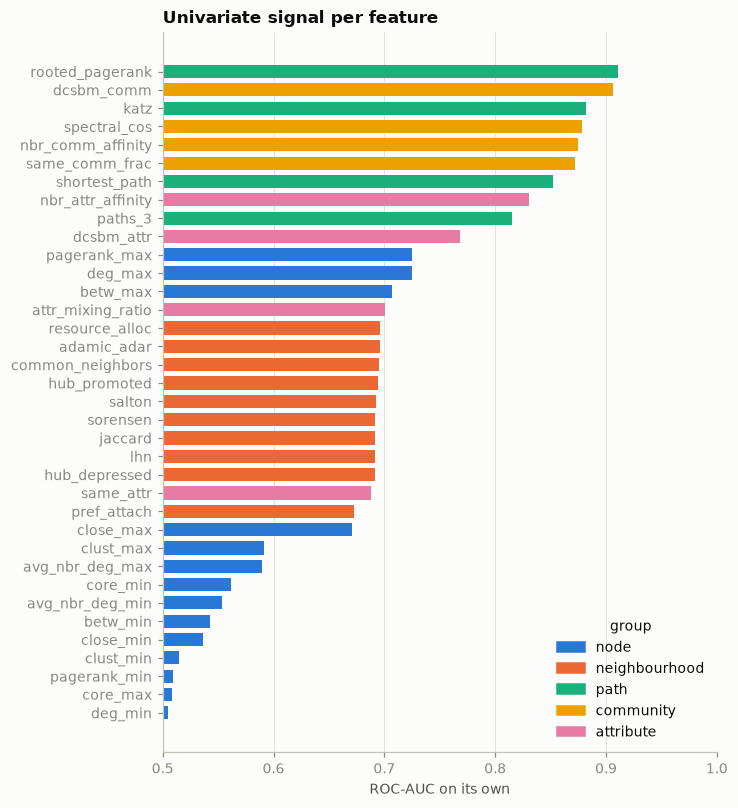

In [12]:
auc_raw = pd.Series({f: roc_auc_score(train.label, train[f]) for f in FEATURES})
auc = np.maximum(auc_raw, 1 - auc_raw)
order = auc.sort_values().index

fig, ax = plt.subplots(figsize=(6.5, 8.5))
group_names = list(FEATURE_GROUPS)
ax.barh(range(len(order)), auc[order] - 0.5, left=0.5, height=0.72,
        color=[C[group_names.index(GROUP_OF[f])] for f in order])
ax.set_yticks(range(len(order)), order)
ax.set_xlim(0.5, 1)
ax.set(xlabel='ROC-AUC on its own', title='Univariate signal per feature')
ax.grid(axis='y', visible=False)
ax.legend(handles=[mpl.patches.Patch(color=C[i], label=g) for i, g in enumerate(group_names)],
          title='group', loc='lower right')
plt.show()

### 6.2 Distributions of the strongest features: links vs non-links

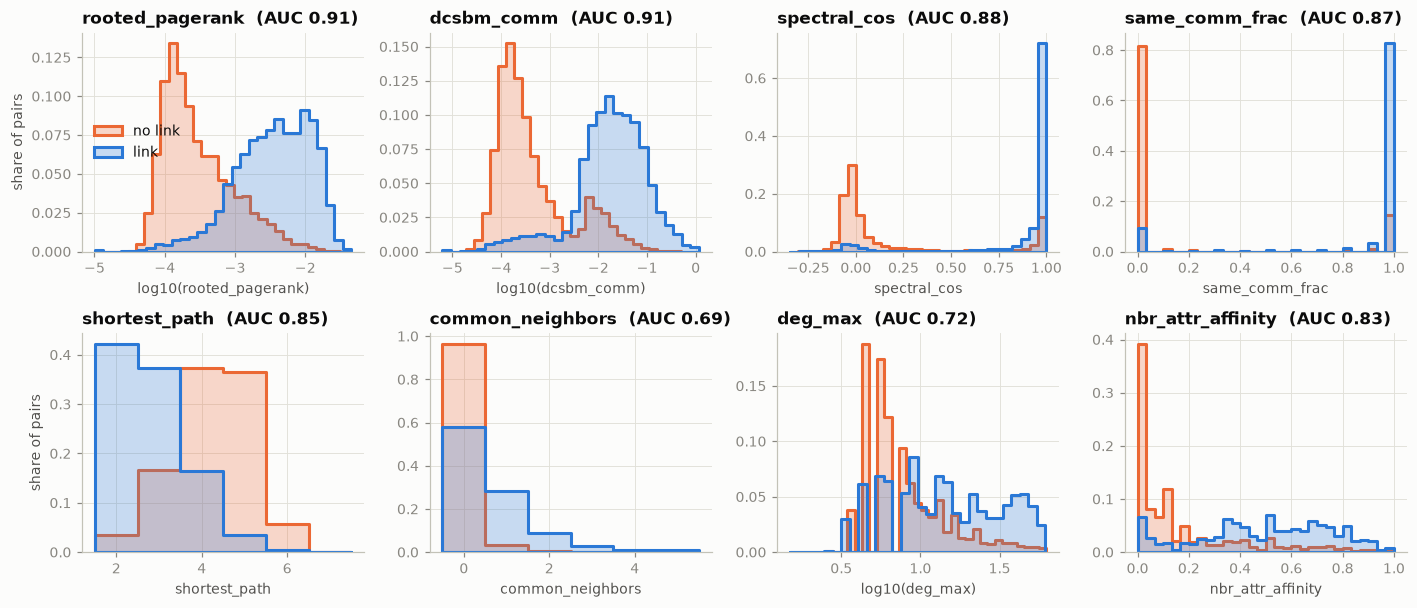

In [13]:
show = [('rooted_pagerank', True), ('dcsbm_comm', True), ('spectral_cos', False), ('same_comm_frac', False),
        ('shortest_path', False), ('common_neighbors', False), ('deg_max', True), ('nbr_attr_affinity', False)]

fig, axes = plt.subplots(2, 4, figsize=(13, 5.6))
for ax, (feat, log) in zip(axes.flat, show):
    x = train[feat]
    if log:
        x = np.log10(x + x[x > 0].min() / 2)                 # small offset so zeros stay visible
    discrete = feat in ('shortest_path', 'common_neighbors')
    if discrete:
        x = x.clip(upper=7 if feat == 'shortest_path' else 5)
    for label, color, name in [(0, NEG, 'no link'), (1, POS, 'link')]:
        sns.histplot(x[train.label == label], ax=ax, stat='probability', discrete=discrete, bins=None if discrete else 30,
                     element='step', fill=True, alpha=0.25, color=color, linewidth=2, label=name)
    ax.set(title=f'{feat}  (AUC {auc[feat]:.2f})', xlabel=f'log10({feat})' if log else feat, ylabel='')
axes[0, 0].set_ylabel('share of pairs')
axes[1, 0].set_ylabel('share of pairs')
axes[0, 0].legend(loc='center left')
plt.tight_layout()
plt.show()

### 6.3 Redundancy

Spearman rank correlation between features, clustered so that redundant blocks sit together.

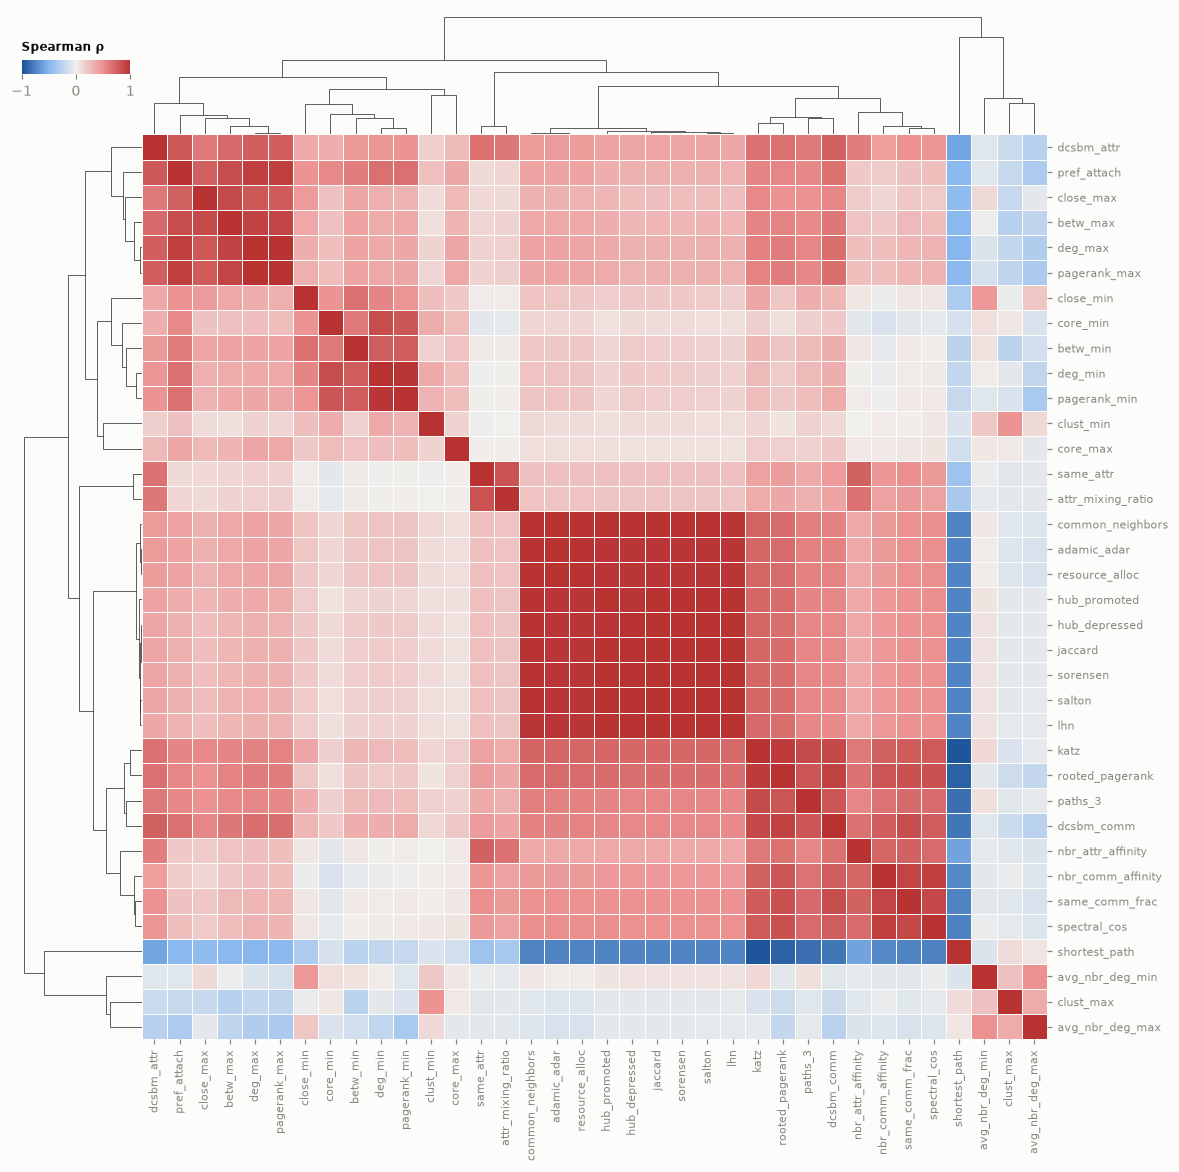

pairs with |ρ| > 0.95:
jaccard           sorensen          1.000
sorensen          hub_depressed     1.000
jaccard           hub_depressed     1.000
adamic_adar       resource_alloc    0.999
jaccard           salton            0.999
salton            sorensen          0.999
                  lhn               0.998
                  hub_depressed     0.997
deg_max           pagerank_max      0.997
jaccard           lhn               0.996
sorensen          lhn               0.996
common_neighbors  adamic_adar       0.995
hub_depressed     lhn               0.995
salton            hub_promoted      0.993
common_neighbors  resource_alloc    0.992
hub_promoted      lhn               0.992
jaccard           hub_promoted      0.987
sorensen          hub_promoted      0.987
common_neighbors  salton            0.986
                  jaccard           0.985
                  sorensen          0.985
                  hub_promoted      0.985
                  hub_depressed     0.985
hub_promote

In [14]:
rho = train[FEATURES].corr(method='spearman')
g = sns.clustermap(rho, cmap=DIV, vmin=-1, vmax=1, center=0, figsize=(11, 11), linewidths=0.4, linecolor='#fcfcfb',
                   dendrogram_ratio=0.12, cbar_pos=(0.015, 0.935, 0.09, 0.012),
                   cbar_kws={'orientation': 'horizontal', 'ticks': [-1, 0, 1]},
                   xticklabels=True, yticklabels=True)
g.ax_heatmap.tick_params(labelsize=7)
g.ax_heatmap.set(xlabel='', ylabel='')
g.ax_cbar.set_title('Spearman ρ', fontsize=8, loc='left')
plt.show()

upper = rho.where(np.triu(np.ones(rho.shape, dtype=bool), k=1)).stack()
print('pairs with |ρ| > 0.95:')
print(upper[upper.abs() > 0.95].sort_values(ascending=False).round(3).to_string())

### 6.4 Train/test shift

Training features come from the slightly sparser graphs $G_k$, and test features from $G$. For each feature we measure how well it alone separates training pairs from test pairs (AUC, 0.5 = identical distributions). Both sets are 50/50 links, so any difference is a shift and not a label effect. We also show the ratio of test to training means.

We do this one feature at a time on purpose. A multivariate "adversarial validation" classifier is misleading here: node-level values such as PageRank are exact floats that differ between graphs, so a random forest can fingerprint which graph a row came from (in a trial run it reached 0.98 AUC that way).

In [15]:
is_test = np.r_[np.zeros(len(train)), np.ones(len(test))]
shift = pd.Series({f: roc_auc_score(is_test, np.r_[train[f], test[f]]) for f in FEATURES})
shift = np.maximum(shift, 1 - shift)

report = pd.DataFrame({
    'group': pd.Series(GROUP_OF),
    'auc': auc,
    'higher_means': np.where(auc_raw >= 0.5, 'link', 'no link'),
    'shift_auc': shift,
    'test/train mean': test[FEATURES].mean() / train[FEATURES].mean(),
}).loc[FEATURES]
report.sort_values('shift_auc', ascending=False).round(3)

,group,auc,higher_means,shift_auc,test/train mean
close_min,node,0.537,link,0.595,1.024
core_min,node,0.562,no link,0.578,1.064
close_max,node,0.670,link,0.564,1.018
deg_min,node,0.505,no link,0.559,1.078
avg_nbr_deg_min,node,0.553,no link,0.540,1.053
pref_attach,neighbourhood,0.673,link,0.535,1.104
avg_nbr_deg_max,node,0.589,no link,0.533,1.036
clust_min,node,0.515,no link,0.533,1.167
shortest_path,path,0.852,no link,0.530,0.962
paths_3,path,0.816,link,0.525,1.216


### 6.5 Feature group ablation (sanity check)

This is a quick linear check of how much each group contributes. It is not model selection, which happens in section 9. Logistic regression on standardised features, with 5-fold cross-validation **grouped by hold-out fold**, so pairs scored on the same graph never sit on both sides of a split.

The last row drops both the attribute *and* the community features. It tells us whether community structure was acting as a proxy for the sensitive attribute.

In [16]:
def cv_scores(cols):
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
    s = cross_validate(model, train[cols], train.label, groups=train.fold, cv=GroupKFold(n_splits=5),
                       scoring=['accuracy', 'roc_auc'])
    return {'accuracy': s['test_accuracy'].mean(), 'roc_auc': s['test_roc_auc'].mean(), 'n_features': len(cols)}


feature_sets = {'all features': FEATURES}
feature_sets |= {f'only {g}': fs for g, fs in FEATURE_GROUPS.items()}
feature_sets |= {f'all except {g}': [f for f in FEATURES if GROUP_OF[f] != g] for g in FEATURE_GROUPS}
feature_sets['all except attribute & community'] = [f for f in FEATURES if GROUP_OF[f] not in ('attribute', 'community')]
ablation = pd.DataFrame({name: cv_scores(cols) for name, cols in feature_sets.items()}).T
ablation.astype({'n_features': int}).round(3)

,accuracy,roc_auc,n_features
all features,0.874,0.933,36
only node,0.694,0.767,14
only neighbourhood,0.702,0.748,10
only path,0.821,0.901,4
only community,0.861,0.900,4
only attribute,0.802,0.850,4
all except node,0.864,0.916,22
all except neighbourhood,0.873,0.933,26
all except path,0.873,0.933,32
all except community,0.853,0.923,32


- **Community features are the backbone.** On their own they reach almost the accuracy of all features, and removing them costs the most.
- **Path features** (rooted PageRank, Katz) are the second-best group. Neighbourhood features add nothing once path features are present, because they only see 2-hop structure.
- **The attribute adds nothing once community features are present**, yet dropping attribute *and* community features costs about 3 points. In other words, the community features carry the attribute's signal. For the ethics essay: deleting the sensitive column does not remove its influence on predictions (proxy discrimination / redundant encoding).

## 7. Selection and export

A transparent rule for a recommended subset (the full candidate set is kept too, and sections 9–10 compare both):
1. **Signal:** univariate AUC ≥ 0.55.
2. **Robustness:** shift AUC ≤ 0.56 (drops features whose training distribution differs most from test).
3. **Redundancy:** go through the remaining features from strongest to weakest and skip any with |ρ| > 0.95 to a feature already kept.

Rule 1 can discard a feature that only helps in combination with others, which is one more reason to keep both sets for model selection.

In [17]:
MIN_AUC, MAX_SHIFT, MAX_RHO = 0.55, 0.56, 0.95

selected, reasons = [], {}
for f in auc.sort_values(ascending=False).index:
    if auc[f] < MIN_AUC:
        reasons[f] = f'weak signal (AUC {auc[f]:.3f})'
    elif shift[f] > MAX_SHIFT:
        reasons[f] = f'train/test shift (shift AUC {shift[f]:.3f})'
    elif (twin := next((s for s in selected if abs(rho.loc[f, s]) > MAX_RHO), None)) is not None:
        reasons[f] = f'redundant with {twin} (ρ = {rho.loc[f, twin]:.3f})'
    else:
        selected.append(f)

print(f'selected {len(selected)} of {len(FEATURES)} features:')
for f in selected:
    print(f'  {f:<20} {GROUP_OF[f]:<14} AUC {auc[f]:.3f}')
print('\ndropped:')
for f, why in reasons.items():
    print(f'  {f:<20} {why}')

selected 18 of 36 features:
  rooted_pagerank      path           AUC 0.911
  dcsbm_comm           community      AUC 0.906
  katz                 path           AUC 0.882
  spectral_cos         community      AUC 0.879
  nbr_comm_affinity    community      AUC 0.874
  same_comm_frac       community      AUC 0.872
  nbr_attr_affinity    attribute      AUC 0.830
  paths_3              path           AUC 0.816
  dcsbm_attr           attribute      AUC 0.768
  pagerank_max         node           AUC 0.725
  betw_max             node           AUC 0.706
  attr_mixing_ratio    attribute      AUC 0.700
  resource_alloc       neighbourhood  AUC 0.696
  same_attr            attribute      AUC 0.688
  pref_attach          neighbourhood  AUC 0.673
  clust_max            node           AUC 0.591
  avg_nbr_deg_max      node           AUC 0.589
  avg_nbr_deg_min      node           AUC 0.553

dropped:
  shortest_path        redundant with katz (ρ = -0.966)
  deg_max              redundant with page

In [18]:
OUTPUT.mkdir(parents=True, exist_ok=True)
meta = lambda df: df.assign(attr_u=attr[df.u], attr_v=attr[df.v])   # raw attributes, for fairness analysis only
meta(train)[['fold', 'u', 'v', 'label', 'attr_u', 'attr_v'] + FEATURES].to_csv(OUTPUT / 'train_features.csv', index=False)
meta(test)[['ID', 'u', 'v', 'attr_u', 'attr_v'] + FEATURES].to_csv(OUTPUT / 'test_features.csv', index=False)
(OUTPUT / 'feature_groups.json').write_text(json.dumps({
    'groups': FEATURE_GROUPS,
    'selected': selected,
    'sensitive': FEATURE_GROUPS['attribute'],
    'config': {'seed': SEED, 'n_folds': N_FOLDS, 'neg_ratio': NEG_RATIO, 'n_louvain': N_LOUVAIN},
}, indent=2))
print(sorted(p.name for p in OUTPUT.iterdir()))

['feature_groups.json', 'test_features.csv', 'train_features.csv']


## 8. Validation design

We use two complementary estimates:

1. **Grouped cross-validation** on the training pairs: `GroupKFold` with 5 splits over the 20 hold-out folds. It is fast, so we use it to tune hyperparameters. Pairs from the same hold-out fold were scored on the same graph, so they always stay on the same side of a split.
2. **Shift-aware pseudo-test.** Cross-validation happens entirely inside the training graphs, so it cannot see the train/test shift (section 6.4): training graphs are slightly sparser than the graph the test pairs are scored on. We therefore repeat the *whole* pipeline one level down.
   - Hide 10% of the visible edges. These are the pseudo-test positives, and the same number of uniform non-edges are the pseudo-test negatives.
   - Build a pseudo-training set from the remaining graph with exactly the same K-fold procedure.
   - Score the pseudo-test pairs on the remaining graph.

   This reproduces how the real training and test sets relate to each other, but with known labels. We repeat it 5 times with different hidden edges.

**Models:** methods from the lectures, namely logistic regression, k-nearest neighbours, a decision tree, a random forest and gradient boosting, plus a soft-voting **ensemble** that averages the probabilities of the tuned random forest, logistic regression and gradient boosting models. Each is tried on two feature sets: all 36 features and the 18 selected in section 7.

**Decision rule:** the test set is exactly balanced (708 / 708). Besides the usual 0.5 probability cut-off, we can label the top half of the scores as links. That rule only needs the *ranking* to be right, so it is immune to probabilities that are shifted as a whole.

In [19]:
CV = GroupKFold(n_splits=5)
SCALERS = [StandardScaler(), QuantileTransformer(output_distribution='normal', random_state=SEED)]
MODELS = {
    'logistic regression': (
        Pipeline([('scale', StandardScaler()), ('clf', LogisticRegression(max_iter=5000))]),
        {'scale': SCALERS, 'clf__C': [0.01, 0.1, 1, 10]}),
    'k-NN': (
        Pipeline([('scale', StandardScaler()), ('clf', KNeighborsClassifier())]),
        {'scale': SCALERS, 'clf__n_neighbors': [15, 31, 61, 121], 'clf__weights': ['uniform', 'distance']}),
    'decision tree': (
        DecisionTreeClassifier(random_state=SEED),
        {'max_depth': [3, 5, 8, 12], 'min_samples_leaf': [5, 20, 50]}),
    'random forest': (
        RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
        {'max_features': ['sqrt', 0.3], 'min_samples_leaf': [1, 5, 20]}),
    'gradient boosting': (
        HistGradientBoostingClassifier(max_iter=300, random_state=SEED),
        {'learning_rate': [0.05, 0.1], 'max_leaf_nodes': [15, 31], 'min_samples_leaf': [20, 50]}),
}
ENSEMBLE_MEMBERS = ['random forest', 'logistic regression', 'gradient boosting']
FEATURE_SETS = {'all': FEATURES, 'selected': selected}


def top_half(scores, seed=SEED):
    """Label the highest-scoring half of the pairs as links (the test set is exactly balanced).

    Ties are broken at random, never by row order: our pseudo-test and training rows are sorted by label,
    so an order-based tie-break would leak the labels (a shallow tree produces many tied scores)."""
    scores = np.asarray(scores)
    order = np.lexsort((np.random.default_rng(seed).random(len(scores)), -scores))
    pred = np.zeros(len(scores), dtype=int)
    pred[order[: len(scores) // 2]] = 1
    return pred

Scaling only matters for logistic regression and k-NN. The grid lets them choose between standardisation and a quantile transform, which tames the heavy-tailed count features (degrees, path counts).

## 9. Model selection with grouped cross-validation

In [20]:
def readable(params):
    return ', '.join(f"{k.removeprefix('clf__')}={type(v).__name__ if hasattr(v, 'fit') else v}" for k, v in params.items())


t0 = time.time()
best, search_rows = {}, []
for fs_name, cols in FEATURE_SETS.items():
    for name, (estimator, grid) in MODELS.items():
        search = GridSearchCV(estimator, grid, cv=CV, scoring='accuracy',   # forest and boosting parallelise themselves
                              n_jobs=1 if name in ('random forest', 'gradient boosting') else -1)
        search.fit(train[cols], train.label, groups=train.fold)
        best[name, fs_name] = search.best_estimator_
        search_rows.append({'model': name, 'features': fs_name, 'cv_accuracy': search.best_score_,
                            'cv_std': search.cv_results_['std_test_score'][search.best_index_],
                            'best hyperparameters': readable(search.best_params_)})
    # soft-voting ensemble of the tuned members (no extra tuning)
    ensemble = VotingClassifier([(m, best[m, fs_name]) for m in ENSEMBLE_MEMBERS], voting='soft')
    scores = cross_validate(ensemble, train[cols], train.label, groups=train.fold, cv=CV, scoring='accuracy')['test_score']
    best['ensemble', fs_name] = ensemble
    search_rows.append({'model': 'ensemble', 'features': fs_name, 'cv_accuracy': scores.mean(), 'cv_std': scores.std(),
                        'best hyperparameters': 'average of ' + ', '.join(ENSEMBLE_MEMBERS)})
print(f'grid search: {time.time() - t0:.0f}s')
cv_results = pd.DataFrame(search_rows).set_index(['model', 'features'])
cv_results.round(3)

grid search: 72s


,,cv_accuracy,cv_std,best hyperparameters
model,features,,,
logistic regression,all,0.874,0.005,"C=1, scale=StandardScaler"
k-NN,all,0.869,0.008,"n_neighbors=31, weights=distance, scale=Standa..."
decision tree,all,0.870,0.008,"max_depth=5, min_samples_leaf=20"
random forest,all,0.875,0.009,"max_features=sqrt, min_samples_leaf=20"
gradient boosting,all,0.875,0.006,"learning_rate=0.05, max_leaf_nodes=15, min_sam..."
ensemble,all,0.875,0.007,"average of random forest, logistic regression,..."
logistic regression,selected,0.866,0.009,"C=1, scale=QuantileTransformer"
k-NN,selected,0.866,0.008,"n_neighbors=61, weights=distance, scale=Standa..."
decision tree,selected,0.869,0.007,"max_depth=5, min_samples_leaf=50"


## 10. Shift-aware validation on a pseudo-test

Hyperparameters stay fixed at the values chosen above, and only the training data changes. One small caveat: they were tuned on the real training set, whose positives include the edges hidden here. With a handful of discrete choices this has a negligible effect on the estimate.

In [21]:
def pseudo_test_round(seed):
    """One level down: hide 10% of G's edges and rebuild the training set from what remains."""
    rng = np.random.default_rng(seed)
    hidden = E[rng.choice(len(E), size=round(0.1 * len(E)), replace=False)]
    G_p = G.copy()
    G_p.remove_edges_from(map(tuple, hidden))
    neg = sample_non_edges(len(hidden), set(map(tuple, E)) | test_set, rng)
    pairs = np.vstack([hidden, neg])
    pseudo_test = pd.DataFrame(pairs, columns=['u', 'v']).assign(label=np.r_[np.ones(len(hidden), int), np.zeros(len(neg), int)])
    pseudo_test = pd.concat([pseudo_test, pair_features(G_p, pairs, seed=seed)], axis=1)
    pseudo_train = build_dataset(G_p, exclude=set(map(tuple, pairs)) | test_set, seed=seed)
    return pseudo_train, pseudo_test


N_PSEUDO = 5
t0 = time.time()
pseudo_rounds = [pseudo_test_round(SEED + 1000 * (r + 1)) for r in range(N_PSEUDO)]
print(f'{N_PSEUDO} pseudo-test rounds built in {time.time() - t0:.0f}s')

rows = []
for r, (p_train, p_test) in enumerate(pseudo_rounds):
    for (name, fs_name), model in best.items():
        cols = FEATURE_SETS[fs_name]
        proba = clone(model).fit(p_train[cols], p_train.label).predict_proba(p_test[cols])[:, 1]
        rows.append({'round': r, 'model': name, 'features': fs_name,
                     'pseudo_acc_0.5': accuracy_score(p_test.label, proba >= 0.5),
                     'pseudo_acc_top_half': accuracy_score(p_test.label, top_half(proba)),
                     'pseudo_auc': roc_auc_score(p_test.label, proba),
                     'predicted_link_share_0.5': (proba >= 0.5).mean()})
pseudo = pd.DataFrame(rows)

comparison = cv_results[['cv_accuracy']].join(
    pseudo.groupby(['model', 'features']).agg(
        pseudo_acc_0_5=('pseudo_acc_0.5', 'mean'), pseudo_acc_0_5_std=('pseudo_acc_0.5', 'std'),
        pseudo_acc_top_half=('pseudo_acc_top_half', 'mean'), pseudo_acc_top_half_std=('pseudo_acc_top_half', 'std'),
        pseudo_auc=('pseudo_auc', 'mean'), predicted_link_share_0_5=('predicted_link_share_0.5', 'mean')))
comparison.sort_values('pseudo_acc_0_5', ascending=False).round(3)

5 pseudo-test rounds built in 262s


cv_accuracy  pseudo_acc_0_5  pseudo_acc_0_5_std  \
model               features                                                    
ensemble            all             0.875           0.878               0.011   
gradient boosting   all             0.875           0.876               0.011   
random forest       all             0.875           0.875               0.012   
ensemble            selected        0.873           0.875               0.014   
gradient boosting   selected        0.873           0.875               0.015   
random forest       selected        0.872           0.874               0.012   
logistic regression all             0.874           0.874               0.014   
k-NN                all             0.869           0.874               0.011   
                    selected        0.866           0.872               0.012   
decision tree       all             0.870           0.869               0.013   
logistic regression selected        0.866           0.869               0.010   
decision tree       selected        0.869           0.869               0.014   

                              pseudo_acc_top_half  pseudo_acc_top_half_std  \
model               features                                                 
ensemble            all                     0.876                    0.011   
gradient boosting   all                     0.876                    0.011   
random forest       all                     0.872                    0.013   
ensemble            selected                0.871                    0.014   
gradient boosting   selected                0.872                    0.013   
random forest       selected                0.871                    0.016   
logistic regression all                     0.871                    0.012   
k-NN                all                     0.867                    0.015   
                    selected                0.864                    0.016   
decision tree       all                     0.866                    0.011   
logistic regression selected                0.867                    0.012   
decision tree       selected                0.863                    0.010   

                              pseudo_auc  predicted_link_share_0_5  
model               features                                        
ensemble            all            0.938                     0.518  
gradient boosting   all            0.936                     0.510  
random forest       all            0.936                     0.516  
ensemble            selected       0.934                     0.520  
gradient boosting   selected       0.934                     0.514  
random forest       selected       0.932                     0.523  
logistic regression all            0.934                     0.518  
k-NN                all            0.927                     0.519  
                    selected       0.921                     0.522  
decision tree       all            0.923                     0.515  
logistic regression selected       0.928                     0.509  
decision tree       selected       0.921                     0.526

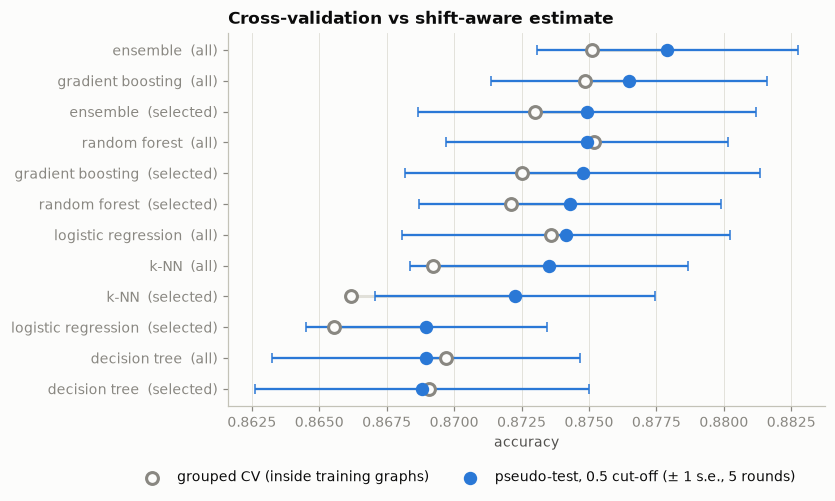

In [22]:
plot_df = comparison.sort_values('pseudo_acc_0_5')
labels_y = [f'{m}  ({f})' for m, f in plot_df.index]
y = np.arange(len(plot_df))
se = plot_df.pseudo_acc_0_5_std / np.sqrt(N_PSEUDO)

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.hlines(y, plot_df.cv_accuracy, plot_df.pseudo_acc_0_5, color=GRID, linewidth=2, zorder=1)
ax.errorbar(plot_df.pseudo_acc_0_5, y, xerr=se, fmt='none', ecolor=C[0], elinewidth=1.5, capsize=3, zorder=2)
ax.scatter(plot_df.cv_accuracy, y, s=60, facecolor='#fcfcfb', edgecolor=MUTED, linewidth=2, zorder=3,
           label='grouped CV (inside training graphs)')
ax.scatter(plot_df.pseudo_acc_0_5, y, s=60, color=C[0], zorder=4,
           label=f'pseudo-test, 0.5 cut-off (± 1 s.e., {N_PSEUDO} rounds)')
ax.set_yticks(y, labels_y)
ax.grid(axis='y', visible=False)
ax.set(xlabel='accuracy', title='Cross-validation vs shift-aware estimate')
ax.legend(loc='upper center', bbox_to_anchor=(0.4, -0.14), ncol=2)
plt.show()

How to read this: the open circle is what cross-validation promises. The filled dot is what the model achieves when trained and tested under the same shift as the real submission, with ± 1 standard error over the rounds. Two observations:
- **With 20 folds the shift is cheap.** Cross-validation and the pseudo-test agree to within about 0.6 points for every model.
- **The model barely matters.** The best combinations (the ensemble, gradient boosting, the random forest, logistic regression and k-NN on all features, plus the ensemble, boosting and forest on the selected features) all reach 0.874–0.878, within about one standard error of each other. This suggests that the data, not the model, sets the ceiling, as the assignment hinted: about 9% of the links cross communities (section 2.3), and about one in six random non-edges falls inside a community (the `same_comm_frac` panel in 6.2), so each of these pairs looks like the other class.

The top-half rule was not better than the 0.5 cut-off for any model, because the models already predict close to 50% links (last column of the table).

## 11. Final model and submission

We pick the combination of model, feature set and decision rule with the best pseudo-test accuracy, refit it on the full training set and predict the test pairs.

In [23]:
rule_means = {'0.5': comparison.pseudo_acc_0_5, 'top half': comparison.pseudo_acc_top_half}
FINAL_RULE = max(rule_means, key=lambda r: rule_means[r].max())
FINAL_MODEL, FINAL_FEATURES = rule_means[FINAL_RULE].idxmax()
final_cols = FEATURE_SETS[FINAL_FEATURES]
final_estimator = best[FINAL_MODEL, FINAL_FEATURES]

print(f'final model:     {FINAL_MODEL} on {FINAL_FEATURES} features ({len(final_cols)})')
print(f'hyperparameters: {cv_results.loc[(FINAL_MODEL, FINAL_FEATURES), "best hyperparameters"]}')
print(f'decision rule:   {FINAL_RULE}')
print(f'grouped CV accuracy:         {cv_results.loc[(FINAL_MODEL, FINAL_FEATURES), "cv_accuracy"]:.3f}')
std_col = 'pseudo_acc_0_5_std' if FINAL_RULE == '0.5' else 'pseudo_acc_top_half_std'
print(f'pseudo-test accuracy (mean): {rule_means[FINAL_RULE][FINAL_MODEL, FINAL_FEATURES]:.3f} '
      f'± {comparison.loc[(FINAL_MODEL, FINAL_FEATURES), std_col]:.3f} (std over {N_PSEUDO} rounds)')

final model:     ensemble on all features (36)
hyperparameters: average of random forest, logistic regression, gradient boosting
decision rule:   0.5
grouped CV accuracy:         0.875
pseudo-test accuracy (mean): 0.878 ± 0.011 (std over 5 rounds)


The ensemble wins, but only by 0.2–0.3 points over its best members (gradient boosting 0.876, random forest 0.875), which is less than one standard error. In a side experiment on the same pseudo-test rounds, averaging was never worse than the random forest alone in any round, so it is a safe choice rather than a big one. Logistic regression on all features (0.874) remains the transparent alternative: its coefficients can be read directly, which is worth mentioning in the transparency part of the essay.

In [24]:
final_model = clone(final_estimator).fit(train[final_cols], train.label)
test_proba = final_model.predict_proba(test[final_cols])[:, 1]
test_pred = top_half(test_proba) if FINAL_RULE == 'top half' else (test_proba >= 0.5).astype(int)

submission = pd.DataFrame({'ID': test.ID, 'prediction': test_pred})
submission.to_csv(OUTPUT.parent / 'submission.csv', index=False)
print(f'share of test pairs predicted as links: {test_pred.mean():.3f} '
      f'(with a 0.5 cut-off it would be {(test_proba >= 0.5).mean():.3f})')
print(f'agreement between the two rules on the test pairs: {(top_half(test_proba) == (test_proba >= 0.5)).mean():.3f}')
submission.head()

share of test pairs predicted as links: 0.515 (with a 0.5 cut-off it would be 0.515)
agreement between the two rules on the test pairs: 0.985


,ID,prediction
0,0,1
1,1,1
2,2,1
3,3,1
4,4,0


## 12. Who gets the errors? (fairness analysis)

The test labels are hidden, so we use **out-of-fold predictions on the training pairs**: grouped CV, where each pair is predicted by a model that never saw its hold-out fold. We compare three versions of the final model:
- with all its features,
- without the attribute features ("fairness through unawareness"),
- without the attribute *and* community features (removing the proxy as well).

We split the pairs two ways:
- **Same-attribute vs cross-attribute pairs.** Does the model under-predict links between groups, and so reinforce segregation, for example in friend recommendations?
- **Degree of the less-connected endpoint.** Are people with few connections served worse?

In [25]:
def rates(y, pred):
    y, pred = np.asarray(y), np.asarray(pred)
    return {'pairs': len(y), 'true link share': y.mean(), 'predicted link share': pred.mean(),
            'accuracy': (y == pred).mean(), 'recall (TPR)': pred[y == 1].mean(), 'false positive rate': pred[y == 0].mean()}


variants = {
    'all features': final_cols,
    'without attribute': [f for f in final_cols if GROUP_OF[f] != 'attribute'],
    'without attribute & community': [f for f in final_cols if GROUP_OF[f] not in ('attribute', 'community')],
}
segments = {
    'same-attribute pairs': attr[train.u] == attr[train.v],
    'cross-attribute pairs': attr[train.u] != attr[train.v],
    'min degree ≤ 3': train.deg_min <= 3,
    'min degree 4–6': train.deg_min.between(4, 6),
    'min degree ≥ 7': train.deg_min >= 7,
}

oof_pred, fairness_rows = {}, []
for variant, cols in variants.items():
    proba = cross_val_predict(clone(final_estimator), train[cols], train.label, groups=train.fold, cv=CV, method='predict_proba')[:, 1]
    oof_pred[variant] = top_half(proba) if FINAL_RULE == 'top half' else (proba >= 0.5).astype(int)
    fairness_rows.append({'variant': variant, 'segment': 'all pairs', **rates(train.label, oof_pred[variant])})
    for seg, mask in segments.items():
        fairness_rows.append({'variant': variant, 'segment': seg, **rates(train.label[mask], oof_pred[variant][mask])})
fairness = pd.DataFrame(fairness_rows).set_index(['variant', 'segment'])
fairness.round(3)

pairs  true link share  \
variant                       segment                                         
all features                  all pairs              12754            0.500   
                              same-attribute pairs    4469            0.768   
                              cross-attribute pairs   8285            0.356   
                              min degree ≤ 3          5169            0.571   
                              min degree 4–6          5826            0.370   
                              min degree ≥ 7          1759            0.723   
without attribute             all pairs              12754            0.500   
                              same-attribute pairs    4469            0.768   
                              cross-attribute pairs   8285            0.356   
                              min degree ≤ 3          5169            0.571   
                              min degree 4–6          5826            0.370   
                              min degree ≥ 7          1759            0.723   
without attribute & community all pairs              12754            0.500   
                              same-attribute pairs    4469            0.768   
                              cross-attribute pairs   8285            0.356   
                              min degree ≤ 3          5169            0.571   
                              min degree 4–6          5826            0.370   
                              min degree ≥ 7          1759            0.723   

                                                     predicted link share  \
variant                       segment                                       
all features                  all pairs                             0.526   
                              same-attribute pairs                  0.863   
                              cross-attribute pairs                 0.344   
                              min degree ≤ 3                        0.601   
                              min degree 4–6                        0.400   
                              min degree ≥ 7                        0.720   
without attribute             all pairs                             0.526   
                              same-attribute pairs                  0.860   
                              cross-attribute pairs                 0.346   
                              min degree ≤ 3                        0.601   
                              min degree 4–6                        0.400   
                              min degree ≥ 7                        0.721   
without attribute & community all pairs                             0.512   
                              same-attribute pairs                  0.816   
                              cross-attribute pairs                 0.349   
                              min degree ≤ 3                        0.595   
                              min degree 4–6                        0.371   
                              min degree ≥ 7                        0.737   

                                                     accuracy  recall (TPR)  \
variant                       segment                                         
all features                  all pairs                 0.875         0.901   
                              same-attribute pairs      0.853         0.966   
                              cross-attribute pairs     0.887         0.824   
                              min degree ≤ 3            0.869         0.912   
                              min degree 4–6            0.875         0.872   
                              min degree ≥ 7            0.894         0.924   
without attribute             all pairs                 0.875         0.901   
                              same-attribute pairs      0.853         0.965   
                              cross-attribute pairs     0.887         0.827   
                              min degree ≤ 3            0.868 

share of true links that are cross-attribute: 0.462
share of predicted links that are cross-attribute (all features): 0.425
share of predicted links that are cross-attribute (without attribute): 0.427
share of predicted links that are cross-attribute (without attribute & community): 0.442


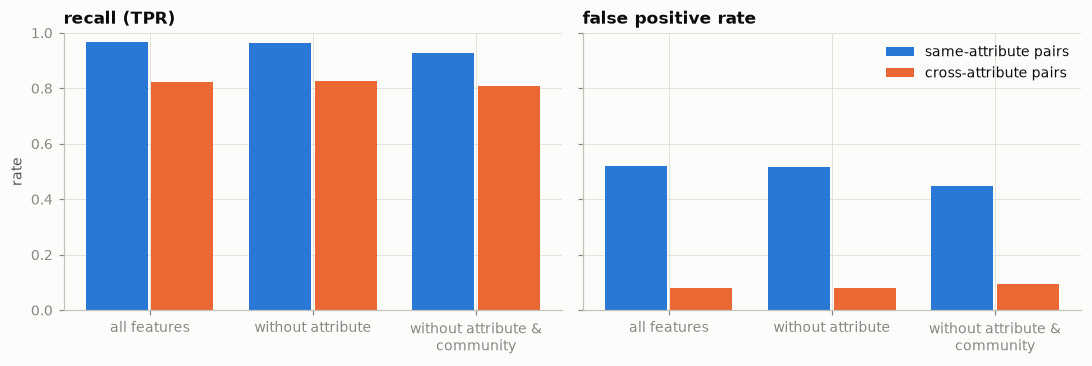

In [26]:
cross = attr[train.u] != attr[train.v]
true_links = train.label.to_numpy() == 1
print(f'share of true links that are cross-attribute: {cross[true_links].mean():.3f}')
for variant, pred in oof_pred.items():
    print(f'share of predicted links that are cross-attribute ({variant}): {cross[pred == 1].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
x = np.arange(len(variants))
w = 0.38
for ax, metric in zip(axes, ['recall (TPR)', 'false positive rate']):
    for i, (seg, color) in enumerate([('same-attribute pairs', C[0]), ('cross-attribute pairs', C[1])]):
        vals = [fairness.loc[(v, seg), metric] for v in variants]
        ax.bar(x + (i - 0.5) * (w + 0.02), vals, w, color=color, label=seg)
    ax.set_xticks(x, [v.replace(' & ', ' &\n') for v in variants])
    ax.set_title(metric)
axes[0].set_ylabel('rate')
axes[0].set_ylim(0, 1)
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

What the numbers say (out-of-fold predictions of the final model):
- **Cross-group links are under-predicted.** 46% of the true links join people with different attributes, but only 43% of the predicted links do. Recall is 0.97 for same-attribute links against 0.82 for cross-attribute links.
- **Same-group strangers get connected.** About half (0.52) of the same-attribute non-links are predicted as links, against 8% of the cross-attribute non-links. Part of this is base rate: 77% of same-attribute training pairs are links, against 36% of cross-attribute pairs. The consequence is the same either way. A friend recommender built on this model would push people towards their own group, a feedback loop that strengthens homophily over time.
- **"Fairness through unawareness" does nothing.** Without the attribute features every number is essentially unchanged. The model never needed the attribute, because the community features carry it.
- **Removing the proxy helps only a little.** Without the community features as well, the gap narrows slightly (false positive rate 0.45 vs 0.09) at the cost of 1.5 points of accuracy. The path features still encode the community structure.
- **Degree matters little.** Accuracy ranges from 0.869 (the less-connected endpoint has degree ≤ 3) to 0.894 (degree ≥ 7), with no consistent pattern in the error rates.

## 13. Error rates per attribute value (input for the ethics essay)

Here we break the final model's errors down by **attribute value** (a–f), with every rate from the confusion matrix.

**Model and folding.** We use the final model from section 11: the soft-voting ensemble with the hyperparameters tuned in section 9, on all 36 features, with a 0.5 cut-off. Each training pair is predicted by a model trained on the other four splits of the grouped 5-fold cross-validation, so it never saw that pair's hold-out fold. These are the same out-of-fold predictions as in section 12. The hyperparameters were tuned on the same splits, so all rates are very slightly optimistic, for every group alike.

**Which pairs count for a group.** A pair has two endpoints and so up to two attribute values. A pair counts for group g when at least one endpoint has value g: it is a decision the model makes about a member of g. A b–f pair therefore counts once for b and once for f. The row `all` holds every pair once.

**Metrics** (a link is the positive class):

| Metric | Formula | Meaning here |
|---|---|---|
| accuracy | (TP + TN) / all pairs | share of pairs classified correctly |
| precision | TP / (TP + FP) | share of predicted links that are real |
| recall (true positive rate) | TP / (TP + FN) | share of real links the model finds |
| specificity (true negative rate) | TN / (TN + FP) | share of non-links the model rejects |
| false positive rate | FP / (FP + TN) = 1 − specificity | share of non-links predicted as links, e.g. strangers recommended as friends |
| false negative rate | FN / (FN + TP) = 1 − recall | share of real links the model misses |

**Uncertainty.** Every rate is also computed separately in each of the 5 splits. The standard error over the splits (error bars in the figure) is only a rough guide, because pairs that share a node are not independent.

In [27]:
y_true, y_pred = train.label.to_numpy(), oof_pred['all features']   # final model, out-of-fold (section 12)
print(f'model: {FINAL_MODEL} on {FINAL_FEATURES} features ({len(final_cols)}), cut-off: {FINAL_RULE}')
for m in ENSEMBLE_MEMBERS if FINAL_MODEL == 'ensemble' else [FINAL_MODEL]:
    print(f'  {m}: {cv_results.loc[(m, FINAL_FEATURES), "best hyperparameters"]}')

METRICS = ['accuracy', 'precision', 'recall', 'specificity', 'false positive rate', 'false negative rate']


def confusion_rates(y, pred):
    """Confusion-matrix rates, with a link as the positive class."""
    tp, fp = np.sum((pred == 1) & (y == 1)), np.sum((pred == 1) & (y == 0))
    tn, fn = np.sum((pred == 0) & (y == 0)), np.sum((pred == 0) & (y == 1))
    return {'pairs': len(y), 'true link share': y.mean(),
            'accuracy': (tp + tn) / len(y), 'precision': tp / (tp + fp), 'recall': tp / (tp + fn),
            'specificity': tn / (tn + fp), 'false positive rate': fp / (fp + tn), 'false negative rate': fn / (fn + tp)}


groups = sorted(set(attr))
attr_u, attr_v = attr[train.u], attr[train.v]
in_group = {g: (attr_u == g) | (attr_v == g) for g in groups} | {'all': np.ones(len(train), dtype=bool)}
per_attr = pd.DataFrame({g: confusion_rates(y_true[mask], y_pred[mask]) for g, mask in in_group.items()}).T

rows = []
for _, held_out in CV.split(train, groups=train.fold):          # the same 5 splits as the out-of-fold predictions
    for g, mask in in_group.items():
        idx = held_out[mask[held_out]]
        rows.append({'attribute': g, **confusion_rates(y_true[idx], y_pred[idx])})
per_attr_se = pd.DataFrame(rows).groupby('attribute', sort=False)[METRICS].std() / np.sqrt(CV.n_splits)
per_attr.astype({'pairs': int}).round(3)

model: ensemble on all features (36), cut-off: 0.5
  random forest: max_features=sqrt, min_samples_leaf=20
  logistic regression: C=1, scale=StandardScaler
  gradient boosting: learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=20


,pairs,true link share,accuracy,precision,recall,specificity,false positive rate,false negative rate
a,3365,0.437,0.856,0.840,0.829,0.877,0.123,0.171
b,3531,0.438,0.863,0.843,0.845,0.877,0.123,0.155
c,3589,0.453,0.884,0.869,0.875,0.891,0.109,0.125
d,3505,0.441,0.890,0.856,0.904,0.879,0.121,0.096
e,3578,0.447,0.882,0.851,0.894,0.873,0.127,0.106
f,3471,0.442,0.902,0.874,0.910,0.896,0.104,0.090
all,12754,0.500,0.875,0.857,0.901,0.849,0.151,0.099


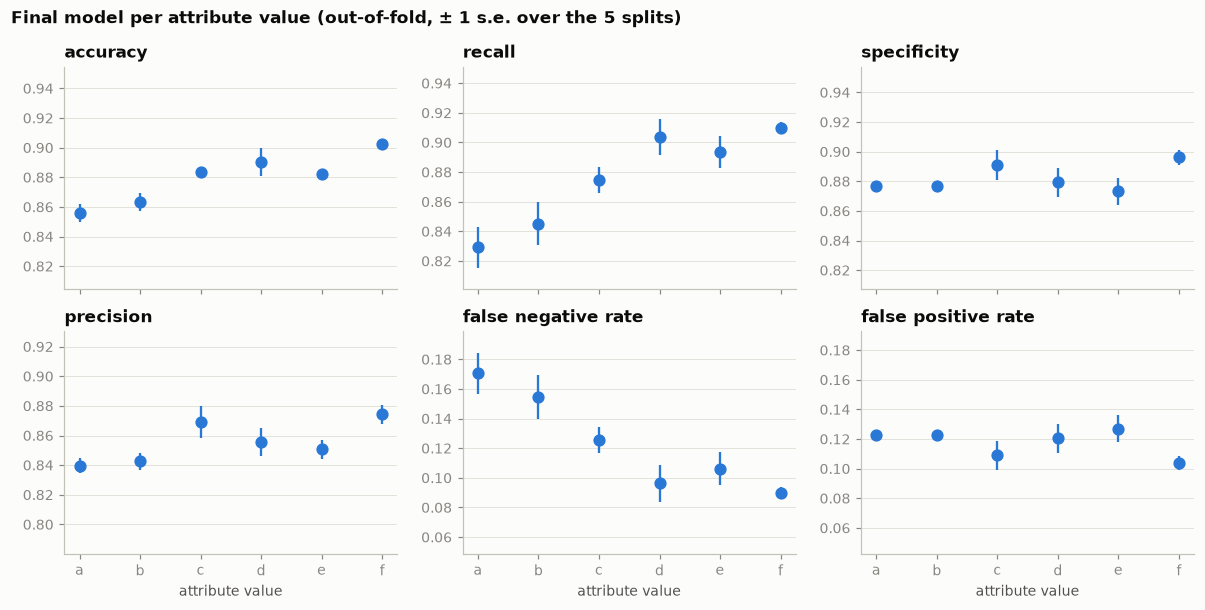

In [28]:
x = np.arange(len(groups))
fig, axes = plt.subplots(2, 3, figsize=(11, 5.6), sharex=True)
for ax, metric in zip(axes.flat, ['accuracy', 'recall', 'specificity', 'precision', 'false negative rate', 'false positive rate']):
    vals = per_attr.loc[groups, metric]
    ax.errorbar(x, vals, yerr=per_attr_se.loc[groups, metric], fmt='o', ms=7, color=C[0], elinewidth=1.5)
    ax.set_ylim(vals.mean() - 0.075, vals.mean() + 0.075)        # same span in every panel, so gaps are comparable
    ax.set_title(metric)
    ax.grid(axis='x', visible=False)
for ax in axes[1]:
    ax.set_xticks(x, groups)
    ax.set_xlabel('attribute value')
fig.suptitle('Final model per attribute value (out-of-fold, ± 1 s.e. over the 5 splits)', x=0.01, ha='left',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Every panel spans the same range (0.15), so a gap of one point looks the same size in each. In the second and third columns the bottom panel is the complement of the one above it (false negative rate = 1 − recall, false positive rate = 1 − specificity). What the numbers say:
- **Accuracy differs by about 5 points between groups**, from 0.856 (a) to 0.902 (f). The standard errors are at most about 1 point.
- **The largest gap is in missed links.** The false negative rate is 17.1% for group a and 15.5% for b, against 9.6% for d and 9.0% for f. Members of a and b have almost twice as many of their real links missed. The gap of about 8 points compares with standard errors of at most 1.5 points.
- **False positives differ much less.** The false positive rate ranges from 0.104 (f) to 0.127 (e), a spread of about 2 points, close to the noise level (standard errors up to 1 point).
- **Precision ranges from 0.840 (a) to 0.874 (f)**, a spread of about 3 points.
- **No group-fairness criterion holds exactly, but the gaps differ in size.** Recall (*equal opportunity*) differs by 8 points between groups, precision (*predictive parity*) by 3 and the false positive rate by 2 (together with recall, *equalised odds*). Missed links are where the model is least fair.

### 13.1 Where the gap comes from

Community features are the backbone of the model (section 6.5), so we expect its errors to depend on whether a pair sits inside a community. Below, each group's links are split by whether the pair is inside one community (`same_comm_frac` ≥ 0.5: at least half of the 10 Louvain runs put the two endpoints together).

In [29]:
across_comm = train.same_comm_frac.to_numpy() < 0.5
is_link = y_true == 1
pd.DataFrame({g: {
    'links': (mask & is_link).sum(),
    'share of links between communities': across_comm[mask & is_link].mean(),
    'recall, links inside a community': y_pred[mask & is_link & ~across_comm].mean(),
    'recall, links between communities': y_pred[mask & is_link & across_comm].mean(),
    'recall, all links': y_pred[mask & is_link].mean(),
} for g, mask in in_group.items()}).T.astype({'links': int}).round(3)

,links,share of links between communities,"recall, links inside a community","recall, links between communities","recall, all links"
a,1471,0.198,0.975,0.237,0.829
b,1545,0.179,0.980,0.225,0.845
c,1626,0.133,0.982,0.171,0.875
d,1547,0.104,0.989,0.168,0.904
e,1599,0.116,0.986,0.194,0.894
f,1535,0.089,0.984,0.147,0.910
all,6377,0.109,0.984,0.223,0.901


- **Given where a link sits, every group is treated about the same.** The model finds about 98% of links inside a community and only 15–24% of links between communities, for every attribute value.
- **What differs is how many of a group's links cross communities.** That share is 20% for a and 18% for b, against 10% for d and 9% for f. Members of a and b have more ties across community lines, and those are exactly the links the model misses. That explains the recall gap.
- **The attribute itself is not the cause.** Section 12 showed that dropping the attribute features changes nothing. The disparity comes from community structure, which is 75% aligned with the attribute (section 2.3). Fairness through unawareness cannot fix this.

**For the ethics essay**
- In a friend recommender, members of groups a and b would see their real links suggested less often: their false negative rate is about twice that of d and f.
- The people hit hardest are those who bridge communities. These are the "weak ties" that give access to new information and opportunities (Granovetter, 1973). A recommender built on this model would under-serve exactly these ties, and more so for some attribute groups than others.
- Caveats: these are out-of-fold predictions on training pairs, because the test labels are hidden. Half the pairs are links, as in the test set. In a real recommender almost all candidate pairs are non-links, so precision would be far lower; the comparisons between groups are what carries over.

## Summary

Numbers are from this run (everything is seeded).

**Data and training design**
- 1800 nodes and 6377 visible edges. Degrees are heavy-tailed. There are 6 hidden communities of about 300 nodes holding about 91% of the edges, and the (possibly sensitive) attribute is a noisy label of the community (about 75% agreement).
- The training pairs are built the way we assume the test pairs were: a 20-fold edge hold-out where each fold's features are computed on the graph without that fold, uniform negatives at 1:1, and test pairs excluded. This removes the leakage of `mimo1.ipynb`, where positives were edges of the graph the features were computed on.
- Cross-validation agrees with the shift-aware pseudo-test to within about 0.6 points, so the hold-out design gives honest numbers (section 10).

**Features** (36 candidates in 5 groups)
- Strongest single features: rooted PageRank (AUC 0.91), DC-SBM with Louvain blocks (0.91), Katz (0.88), spectral cosine (0.88) and community co-membership (0.87).
- The classic common-neighbour indices are weak here (AUC ≈ 0.69) because most hidden edges have no common neighbour (section 6.2). They are also near-duplicates of each other (ρ > 0.97).
- Linear sanity check with grouped CV: all features give 0.874 accuracy; community features alone give 0.861.
- Recommended subset: 18 features (`selected` in `feature_groups.json`). It never beats all 36 features in sections 9–10, so the final model uses all of them.

**Final model:** soft-voting ensemble of a random forest (300 trees, `max_features='sqrt'`, `min_samples_leaf=20`), logistic regression (`C=1`, standardised) and gradient boosting (`learning_rate=0.05`, `max_leaf_nodes=15`), on all 36 features, 0.5 cut-off. Grouped CV accuracy 0.875; shift-aware pseudo-test accuracy 0.878 ± 0.011 (5 rounds), AUC 0.938. The predictions are in `../output/submission.csv` (51.5% of the test pairs predicted as links).

**Model selection**
- Five model families from the lectures, plus their ensemble, were tuned with grouped CV and compared on a pseudo-test that reproduces the real train/test relationship.
- The best combinations are within about one standard error of each other (0.874–0.878), which suggests that the data, not the model, sets the ceiling (section 10).

**For the ethics essay**
- The model's predictions follow community membership: it finds about 98% of the links inside a community but only 15–24% of the links between communities (section 13.1). Community membership is 75% aligned with the sensitive attribute (section 2.3).
- It under-predicts cross-group links (43% of predicted links vs 46% of true links) and predicts half of all same-group non-links as links, which would reinforce segregation in a recommender.
- Dropping the attribute features changes nothing, in the linear check (0.874 → 0.873, section 6.5) and for the final model (section 12), because the community features encode the same information. Dropping the community features as well costs about 3 points in the linear check and 1.5 points for the final model, and narrows the cross-group gap only slightly. Removing the sensitive column does not remove its influence.
- Per attribute value (section 13), members of groups a and b have 15–17% of their real links missed, against 9–10% for d and f. The cause is network position, not the attribute: more of their links cross communities, and the model misses those.

**Limitations (for the report)**
- Accuracy is measured on balanced pairs with uniform negatives, like the test set. In a real recommender almost all candidate pairs are non-links, so precision would be far lower than these numbers suggest.
- The train/test density shift is reduced (20 folds) and measured (pseudo-test), but not eliminated.
- Community features depend on Louvain, a randomised heuristic; we average 10 runs to stabilise them.
- The network is synthetic with planted communities. On real social networks, with stronger triadic closure, neighbourhood features would likely matter more.
- The fairness analysis uses out-of-fold training predictions, because the test labels are hidden.

**Where things go in the report:** feature engineering → sections 2, 4, 6, 7; data preparation → 3, 5; model selection → 8, 9; training and validation → 9, 10; final results → 11; limitations → above. The ethics analysis draws on 2.3, 6.5, 12 and 13.